> **Mitra AI Projects — Course Notebook**  
> This is a real-world applied notebook from the AIML-Engineering-Lab.  
> Read each cell, run the code, and modify it to experiment.  
> Your work saves automatically in your browser.

---


# Post 005 — Support Vector Machines: Drone Motor Fault Detection

**AI Engineering Lab Series**

## The Problem

A drone motor that fails mid-flight is not just inconvenient — it can be catastrophic. Modern drones carry sensors that measure vibration, current, temperature, and acoustic emission in real time. The question is: can we detect a faulty motor from these signals **before** it fails?

This is a binary classification problem with a non-linear decision boundary. There are two types of faults:
- **Bearing wear**: High vibration amplitude, shifted resonance frequency, high acoustic emission
- **Coil short**: High current draw, high temperature, but relatively normal vibration

A linear classifier cannot separate these fault modes from healthy motors cleanly. This is where **kernel SVM** becomes powerful.

## The SVM Idea

SVM finds the **maximum-margin hyperplane** — the decision boundary that is as far as possible from both classes. The data points closest to the boundary are called **support vectors**, and they are the only points that determine the boundary.

| Concept | Meaning |
|---|---|
| **Hyperplane** | The decision boundary (a line in 2D, a plane in 3D, a hyperplane in nD) |
| **Margin** | The distance between the hyperplane and the nearest support vectors |
| **Support Vectors** | The data points that define the margin — remove them and the boundary changes |
| **C parameter** | Controls the trade-off: small C = wider margin, more misclassifications allowed |
| **Kernel trick** | Maps data to higher dimensions implicitly without computing the transformation |
| **RBF kernel** | Most common kernel: creates circular/elliptical decision boundaries |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay, confusion_matrix)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

df = pd.read_csv('../data/drone_motor_fault.csv')
print(f'Shape: {df.shape}')
print(f'Fault rate: {df["motor_fault"].mean():.1%}')
df.head()

Shape: (5000, 7)
Fault rate: 30.0%


,vibration_freq_hz,vibration_amplitude,current_draw_a,temperature_c,acoustic_emission_db,rpm_deviation_pct,motor_fault
0,110.631,0.740,4.284,45.361,59.982,0.316,0
1,121.241,0.955,4.629,40.227,51.438,0.292,0
2,107.598,0.759,4.484,45.113,56.253,0.046,0
3,142.080,1.125,4.246,37.099,58.329,2.000,0
4,105.361,0.749,4.036,46.840,47.142,0.304,0


## 1. EDA: Visualizing the Feature Space

We first look at pairwise feature distributions to understand which features best separate healthy from faulty motors. This tells us whether a linear boundary might work, or if we need a kernel.

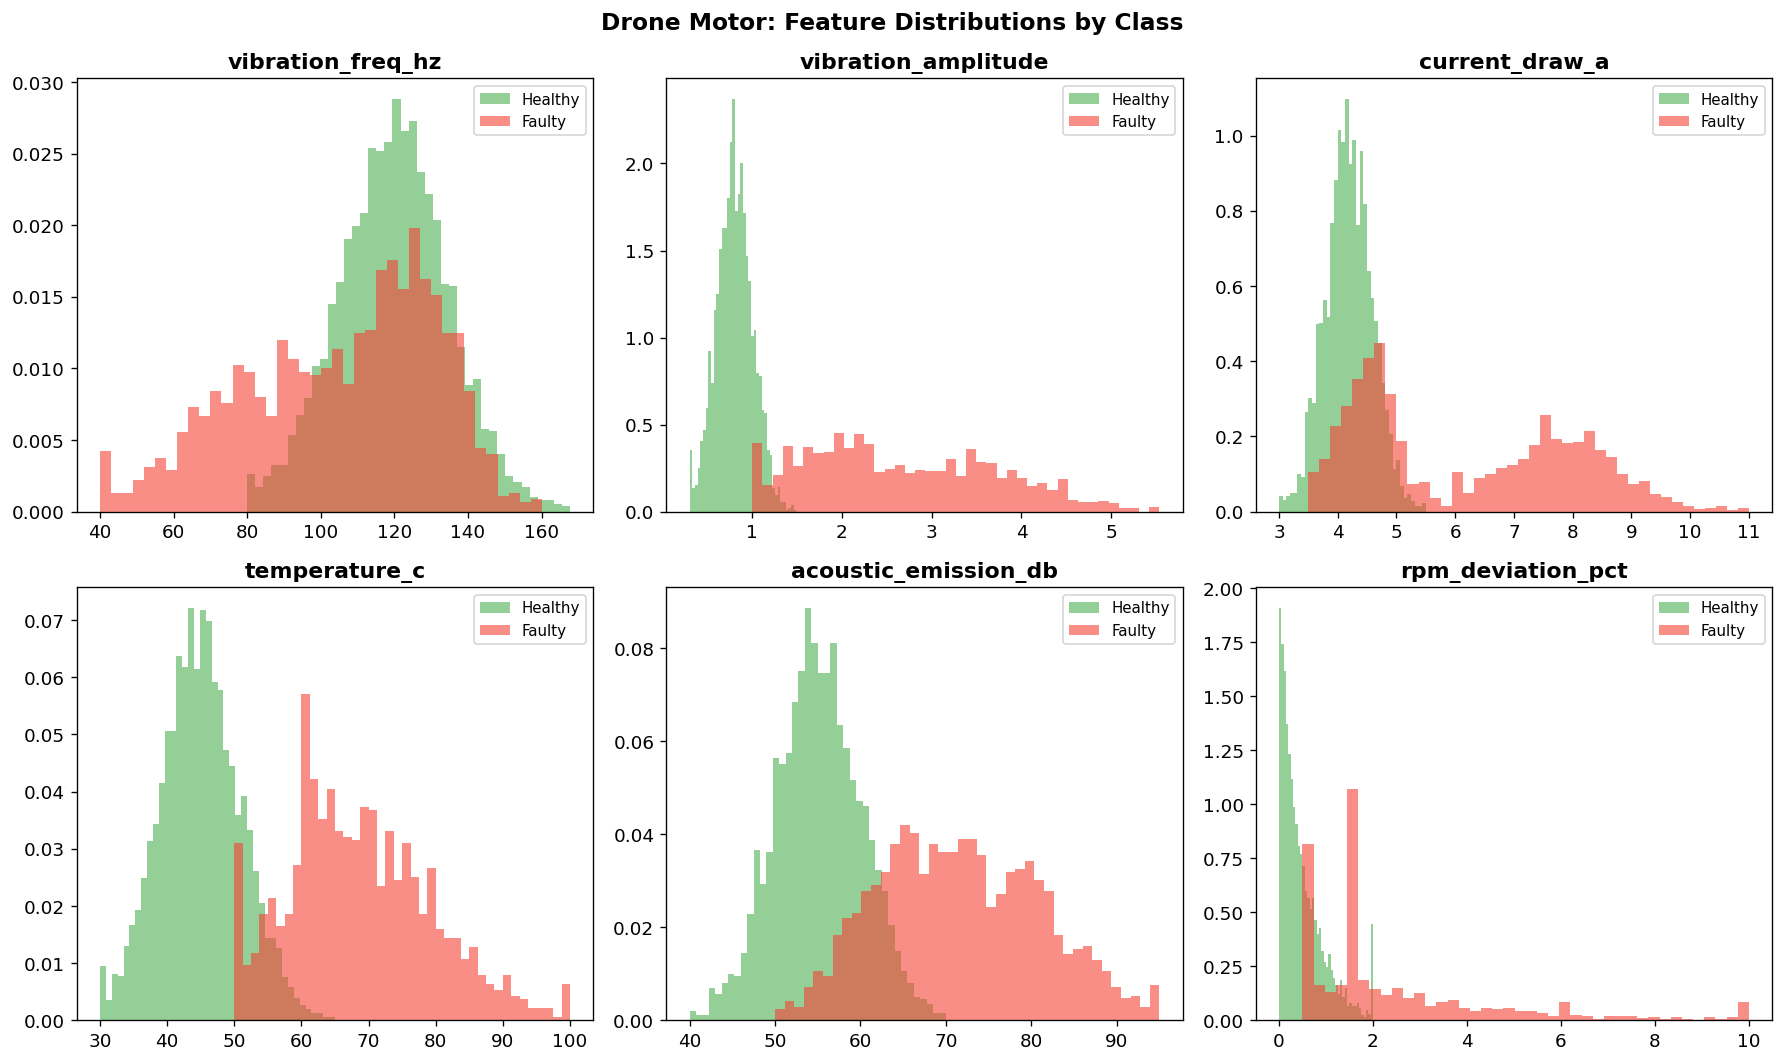

In [2]:
features = ['vibration_freq_hz', 'vibration_amplitude', 'current_draw_a',
            'temperature_c', 'acoustic_emission_db', 'rpm_deviation_pct']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
colors = {0: '#4CAF50', 1: '#F44336'}
labels = {0: 'Healthy', 1: 'Faulty'}

for ax, feat in zip(axes.flatten(), features):
    for cls in [0, 1]:
        data = df[df['motor_fault'] == cls][feat]
        ax.hist(data, bins=40, alpha=0.6, color=colors[cls], label=labels[cls], density=True)
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Drone Motor: Feature Distributions by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/proj1_drone_eda.png', bbox_inches='tight')
plt.show()

## 2. Why SVM Needs Feature Scaling

SVM is **not scale-invariant**. The margin calculation uses Euclidean distances, so a feature with range 0-100 will dominate a feature with range 0-1. We always use `StandardScaler` before SVM.

We use a `Pipeline` to ensure the scaler is fitted only on training data and applied consistently to test data — preventing data leakage.

In [3]:
X = df[features]
y = df['motor_fault']

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(Xtr)} | Test: {len(Xte)}')

# BEFORE: SVM without scaling
svm_raw = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_raw.fit(Xtr, ytr)
print(f'\nBEFORE (no scaling): ROC-AUC = {roc_auc_score(yte, svm_raw.predict_proba(Xte)[:, 1]):.4f}')

# AFTER: SVM with StandardScaler in pipeline
pipe_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42))
])
pipe_rbf.fit(Xtr, ytr)
print(f'AFTER  (with scaling): ROC-AUC = {roc_auc_score(yte, pipe_rbf.predict_proba(Xte)[:, 1]):.4f}')

Train: 4000 | Test: 1000

BEFORE (no scaling): ROC-AUC = 0.9999


AFTER  (with scaling): ROC-AUC = 1.0000


## 3. Kernel Comparison: Linear vs RBF vs Polynomial

The **kernel trick** maps data to a higher-dimensional space where it becomes linearly separable, without explicitly computing the transformation. The three most common kernels are:
- **Linear**: No transformation. Works when classes are linearly separable.
- **RBF (Radial Basis Function)**: Creates circular/elliptical boundaries. Most versatile.
- **Polynomial**: Creates curved polynomial boundaries. Good for structured data.

In [4]:
kernels = [
    ('Linear', 'linear', {}),
    ('RBF', 'rbf', {'gamma': 'scale'}),
    ('Polynomial (degree=3)', 'poly', {'degree': 3, 'gamma': 'scale'}),
]

print('Kernel Comparison:')
results = {}
for name, kernel, kwargs in kernels:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel=kernel, C=1.0, probability=True, random_state=42, **kwargs))
    ])
    pipe.fit(Xtr, ytr)
    proba = pipe.predict_proba(Xte)[:, 1]
    auc = roc_auc_score(yte, proba)
    results[name] = (pipe, proba, auc)
    print(f'  {name:30s}: ROC-AUC = {auc:.4f}')

Kernel Comparison:
  Linear                        : ROC-AUC = 1.0000
  RBF                           : ROC-AUC = 1.0000
  Polynomial (degree=3)         : ROC-AUC = 1.0000


## 4. Hyperparameter Tuning: C and gamma

The two most important SVM hyperparameters are:
- **C**: Regularization. Small C = wider margin, more training errors allowed (underfitting risk). Large C = narrow margin, fewer errors allowed (overfitting risk).
- **gamma** (RBF kernel): Controls the influence radius of each support vector. Small gamma = smooth, large boundary. Large gamma = complex, wiggly boundary.

In [5]:
param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1]
}

pipe_tune = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(pipe_tune, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0)
grid.fit(Xtr, ytr)

print(f'Best params: {grid.best_params_}')
print(f'Best CV AUC: {grid.best_score_:.4f}')
print(f'Test AUC:    {roc_auc_score(yte, grid.best_estimator_.predict_proba(Xte)[:, 1]):.4f}')
print('\nClassification Report:')
print(classification_report(yte, grid.best_estimator_.predict(Xte), target_names=['Healthy', 'Faulty']))

Best params: {'svm__C': 0.1, 'svm__gamma': 'scale'}
Best CV AUC: 1.0000
Test AUC:    1.0000

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       700
      Faulty       1.00      1.00      1.00       300

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



## 5. Decision Boundary Visualization (2D PCA projection)

Since we have 6 features, we use PCA to project to 2D for visualization. This is not the actual decision boundary, but it shows the structure of the data and how the SVM separates the classes.

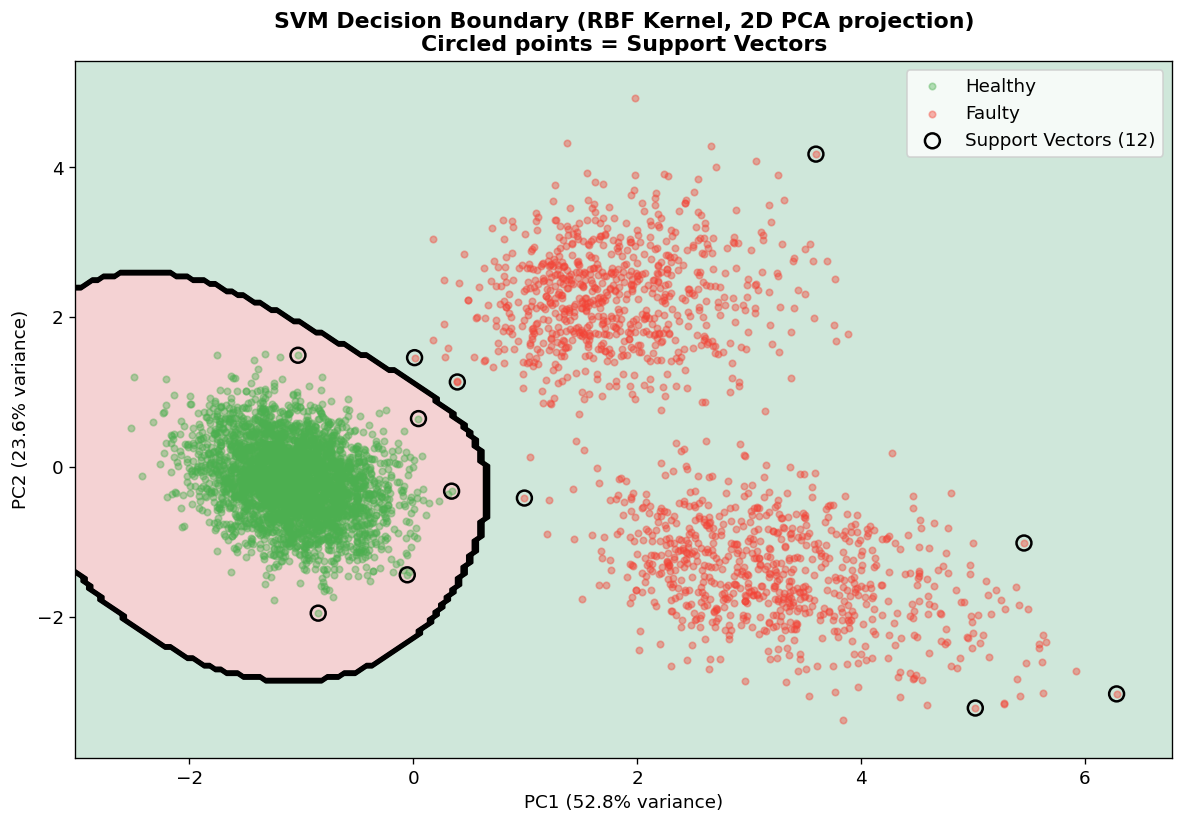

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

# Train SVM in 2D for clean visualization
svm_2d = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svm_2d.fit(X_2d, y)

h = 0.05
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 7))
ax.contourf(xx, yy, Z, alpha=0.2, cmap='RdYlGn')
ax.contour(xx, yy, Z, colors='black', linewidths=1.5)

for cls, color, label in [(0, '#4CAF50', 'Healthy'), (1, '#F44336', 'Faulty')]:
    mask = y == cls
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, alpha=0.4, s=15, label=label)

# Highlight support vectors
sv = svm_2d.support_vectors_
ax.scatter(sv[:, 0], sv[:, 1], s=80, facecolors='none', edgecolors='black',
           linewidths=1.5, label=f'Support Vectors ({len(sv)})')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('SVM Decision Boundary (RBF Kernel, 2D PCA projection)\nCircled points = Support Vectors',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../assets/proj1_drone_decision_boundary.png', bbox_inches='tight')
plt.show()

## 6. Key Takeaways

| Concept | What We Learned |
|---|---|
| **Maximum Margin** | SVM maximizes the gap between classes — this is what makes it robust |
| **Support Vectors** | Only the boundary points matter; the rest of the data is irrelevant |
| **Kernel Trick** | RBF kernel handles non-linear boundaries without explicit feature mapping |
| **C parameter** | Controls bias-variance trade-off; tune with cross-validation |
| **Scaling is mandatory** | SVM uses Euclidean distances — always scale features first |
| **Pipeline** | Prevents data leakage by ensuring scaler is fitted only on training data |